In [2]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Импорт исходной таблицы
users_info = pd.read_csv('data/users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


In [4]:
# Проверка на соответствие типов данных в ячейках 
users_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_user  1000 non-null   int64  
 1   city     1000 non-null   object 
 2   age      912 non-null    float64
 3   gender   911 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


In [5]:
# Проверка на наличие нулов и пропусков
users_info.isnull().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

In [6]:
# Как обрабатывать пропуски в зависимости от их доли:
# < 5% — можно спокойно удалить строки, потери минимальны
# 5–15% — можно удалять, если данных достаточно и выбросы не критичны
# > 15–20% — лучше рассмотреть импутацию или проверить важность колонки
# > 40–50% — импутация обязательна, или удалить саму колонку, если она нерелевантна
share_cnt_null = (users_info.isnull().sum()/len(users_info))*100
print (share_cnt_null)

id_user    0.0
city       0.0
age        8.8
gender     8.9
dtype: float64


In [7]:
# Удаляем нуловые строки и сразу снова проверяем на остатки пропусков
users_info = users_info.dropna()
users_info.isnull().sum()

id_user    0
city       0
age        0
gender     0
dtype: int64

<Axes: ylabel='age'>

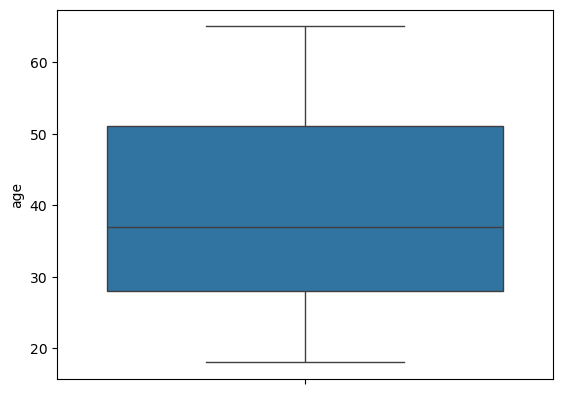

In [8]:
# Перед подробным анализом возраста клиентов посмотрим "ящик с усами" - самое наглядное
# представление о выбросах
sns.boxplot (users_info['age'])

In [9]:
# Рассчитаем границы для выбросов в колонке age с помощью метода IQR 
# (межквартильного размаха).
# Удалим выбросы из таблицы.
q1 = np.percentile (users_info['age'], 25)
q2 = np.percentile (users_info['age'], 50)
q3 = np.percentile (users_info['age'], 75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
print (lower_bound, upper_bound)
users_info_clean = users_info[(users_info['age'] >= lower_bound)\
    & (users_info['age'] <= upper_bound)]
users_info_clean.head()

-6.5 85.5


,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female


In [10]:
# Проанализируем распределение пользователей по полу и по городам.
# Для удобства представления поменям строки и столбцы местами
# Добавим столбец с общим количеством тренировок и долей женщин-клиентов от 
# общего числа пользователей
users_city_cnt = users_info_clean.groupby(['city', 'gender']).\
    agg(cnt_user = ('id_user', 'count')).reset_index()
pivot_users = users_info_clean.pivot_table(
    index=['city'],     
    columns='gender',   
    values='id_user',   
    aggfunc='count',  
    fill_value=0        
).reset_index()
pivot_users['total'] = pivot_users['female'] + pivot_users['male']
pivot_users['share_female'] = pivot_users['female'] / pivot_users['total']
pivot_users.head()

gender,city,female,male,total,share_female
0,Екатеринбург,55,78,133,0.413534
1,Казань,53,77,130,0.407692
2,Москва,220,105,325,0.676923
3,СПб,123,154,277,0.444043


**Вывод:**
Среди пользователей большинство составляют мужчины, поэтому именно на их привлечение 
нужно нацеливать маркетинговые активности. Исключение составляет только Москва, где 
доля женщин-клиентов почти 68%. Для данного города необходим отдельный маркетинговый
план.

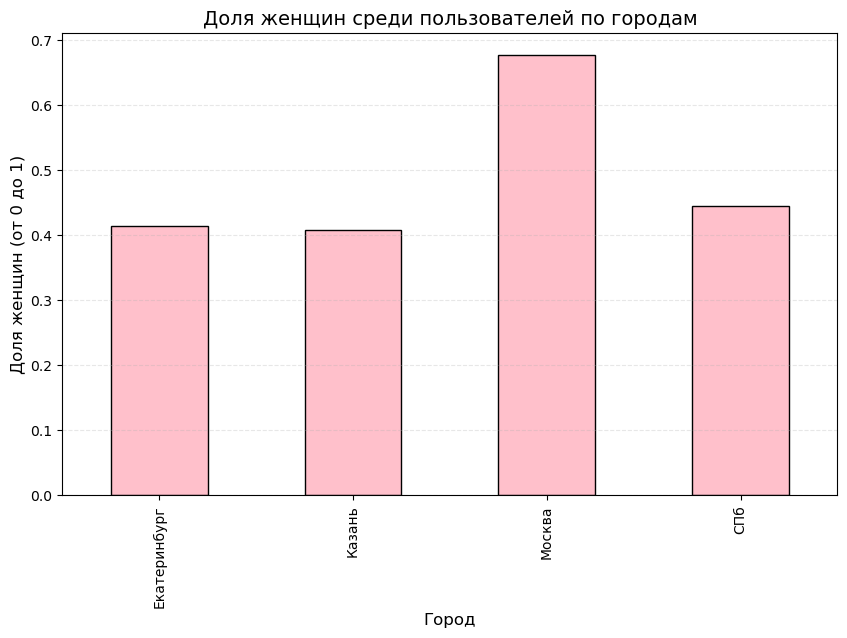

In [11]:
# Построим столбчатую диаграмму (bar chart) для более наглядного результата 
ax = pivot_users.plot.bar(
    x='city',
    y='share_female',
    figsize=(10, 6),
    legend=False,
    color='pink',
    edgecolor='black'
)
ax.set_title('Доля женщин среди пользователей по городам', fontsize=14)
ax.set_xlabel('Город', fontsize=12)
ax.set_ylabel('Доля женщин (от 0 до 1)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [12]:
# Загрузим таблицу с количеством тренировок и их стоимостью (таблица уже очищена от
# нулов, пропусков и выбросов)
pay_mon = pd.read_csv('data/payments_monthly.csv')
pay_mon.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [13]:
# Рассчитаем среднее количество тренировок в месяц для каждого пользователя.
pay_mon_avg  = pay_mon.groupby('id_user')['cnt_total'].mean()
pay_mon_avg = pay_mon_avg.to_frame().reset_index()
pay_mon_avg.rename(columns={'cnt_total': 'cnt_total_avg'}, inplace=True)
pay_mon_avg.head()

,id_user,cnt_total_avg
0,1000,3.666667
1,1001,11.727273
2,1002,11.636364
3,1003,5.166667
4,1004,2.000000


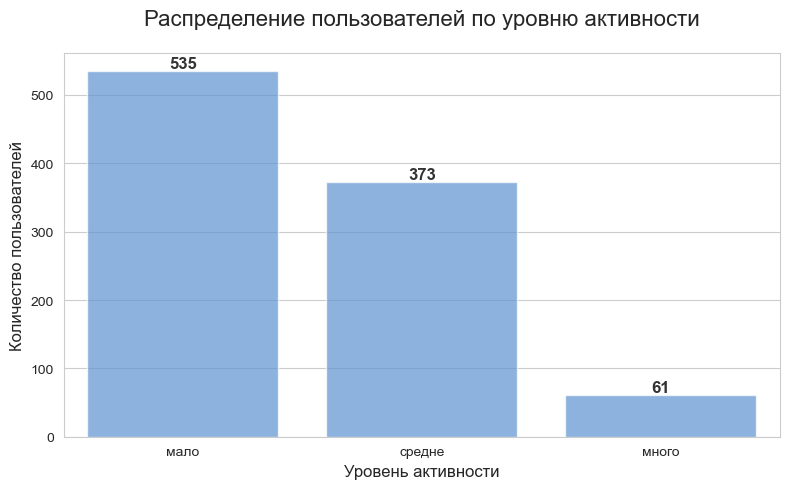

In [25]:
# Разделим пользователей на три группы по уровню активности:
# мало (редко тренируются),
# средне,
# много (тренируются часто).

# Посчитаем, сколько пользователей входит в каждую из этих групп. И для наглядности 
# выводов построим бар-чарт
bins = [0, 6, 12, 50]
labels = ['мало', 'средне', 'много']
pay_mon_avg['div_in_bins'] = pd.cut(pay_mon_avg['cnt_total_avg'], bins=bins, labels=labels, right=True)
pay_mon_counts = pay_mon_avg['div_in_bins'].value_counts()

pay_mon_counts_df = pay_mon_counts.reset_index()
pay_mon_counts_df.columns = ['group', 'count']


category_order = ['мало', 'средне', 'много']
pay_mon_counts_df['group'] = pd.Categorical(pay_mon_counts_df['group'], categories=category_order, ordered=True)
pay_mon_counts_df = pay_mon_counts_df.sort_values('group')


sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=pay_mon_counts_df,
    x='group',
    y='count',
    color='#4A90E2',     
    alpha=0.7             
)

ax.set_title('Распределение пользователей по уровню активности', fontsize=16, pad=20)
ax.set_xlabel('Уровень активности', fontsize=12)
ax.set_ylabel('Количество пользователей', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=12,
        color='#333333',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**Вывод:**
Значительная доля пользователей (535 человек) демонстрирует низкую активность 
(до 6 тренировок в месяц). Это зона роста для бизнеса: потенциал увеличения 
выручки скрыт именно в переводе этих клиентов в категорию „средне“. 
Текущая продуктовая линейка недостаточно мотивирует эту группу к регулярным занятиям.

In [15]:
# Объединяем пользователей и их среднюю активность
df_merged = pd.merge(users_info_clean, pay_mon_avg, on='id_user', how='inner')
# Сразу проверяем, что ничего не потерялось. Оставляем только тех, у кого есть 
# и профиль, и история платежей. Так метрики будут честными.
print('Строк до объединения:', len(users_info_clean))
print('Строк после объединения:', len(df_merged))
print('Доля оставшихся пользователей:', len(df_merged)/len(users_info_clean))

Строк до объединения: 865
Строк после объединения: 838
Доля оставшихся пользователей: 0.96878612716763


In [19]:
# Сделаем агрегацию активности по городам. 
city_activity = (
    df_merged
    .groupby('city')['cnt_total_avg']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'cnt_total_avg': 'avg_cnt_total'})
)

top_city_row = city_activity.iloc[0]
print('Город с самой высокой активностью:', top_city_row['city'])
print('Средняя активность:', round(top_city_row['avg_cnt_total'], 2), 'тренировок в месяц')
print()
print('Распределение по группам активности:')
for group, count in pay_mon_counts.items():
    print(f'   {group}: {count} пользователей')

Город с самой высокой активностью: СПб
Средняя активность: 6.79 тренировок в месяц

Распределение по группам активности:
   мало: 535 пользователей
   средне: 373 пользователей
   много: 61 пользователей


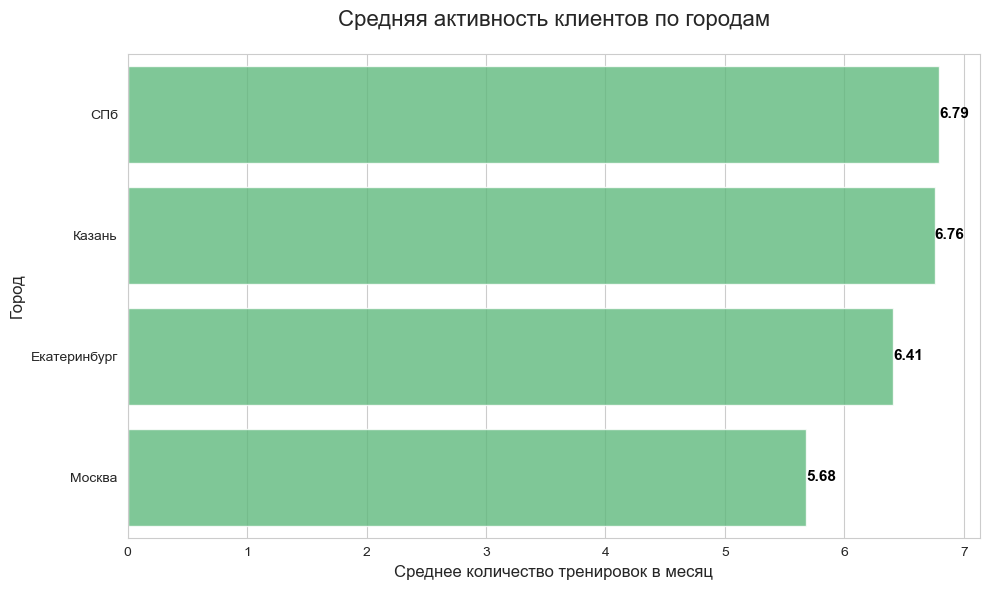

In [24]:
# Построим бар-чарт для наглядности выводов:
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=city_activity,
    x='avg_cnt_total',
    y='city',
    color='#50C878'  # мятный
)

for patch in ax.patches:
    patch.set_alpha(0.8)  
    
ax.set_title('Средняя активность клиентов по городам', fontsize=16, pad=20)
ax.set_xlabel('Среднее количество тренировок в месяц', fontsize=12)
ax.set_ylabel('Город', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        fontsize=11,
        color='black',
        fontweight='bold'  
    )

plt.tight_layout()
plt.show()

**Вывод:**
Разброс средней активности между городами минимальный (всего ~0.4 тренировки в месяц 
между лидером и аутсайдером). Это говорит о выровненном качестве сервиса во всех 
филиалах: клиенты везде ведут себя примерно одинаково.

При этом абсолютный уровень активности (около 6–7 тренировок в месяц) можно считать 
базовым показателем вовлечённости для сети. Для роста выручки стоит фокусироваться 
не на выравнивании городов друг с другом, а на поднятии этой планки для всей сети 
в целом (например, через общие промо-акции или изменение тарифной сетки).